In [107]:
import pandas as pd
import numpy as np 
import openpyxl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
import seaborn as sns

In [108]:
df = pd.read_excel('data/unemployment_rate.xlsx',sheet_name='unemployed_rate')
df.head()

,Date,UnemploymentRate
0,2010-01-01,6.3
1,2010-02-01,6.2
2,2010-03-01,6.1
3,2010-04-01,6.0
4,2010-05-01,5.8


In [109]:
df['Date'] = pd.to_datetime(df['Date'],format='%m/%d/%y')
df = df.sort_values('Date')
df = df.set_index('Date')

df = df.asfreq('MS')

In [110]:
df.head()

,UnemploymentRate
Date,
2010-01-01,6.3
2010-02-01,6.2
2010-03-01,6.1
2010-04-01,6.0
2010-05-01,5.8


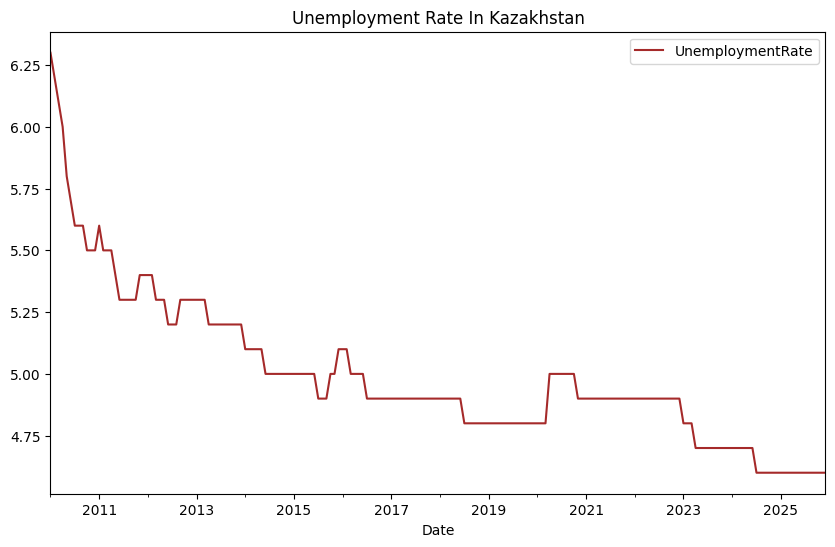

In [111]:
df.plot(figsize=(10,6),title='Unemployment Rate In Kazakhstan',color='brown')
plt.show()

In [112]:
df

,UnemploymentRate
Date,
2010-01-01,6.3
2010-02-01,6.2
2010-03-01,6.1
2010-04-01,6.0
2010-05-01,5.8
...,...
2025-08-01,4.6
2025-09-01,4.6
2025-10-01,4.6


### NAIVE forecast

In [113]:
y = df['UnemploymentRate']

last = y.iloc[-1]

naive_forecast = {
    "t+1": last,
    "t+2": last,
    "t+3": last
}


naive_1 = last
naive_3 = [last, last, last]

print("t+1:", naive_1)
print("t+1..t+3:", naive_3)

t+1: 4.6
t+1..t+3: [np.float64(4.6), np.float64(4.6), np.float64(4.6)]


In [114]:
naive_forecast

{'t+1': np.float64(4.6), 't+2': np.float64(4.6), 't+3': np.float64(4.6)}

In [115]:
train = y.loc["2015-01-01":"2023-12-01"]
test  = y.loc["2024-01-01":"2025-12-01"]

y_pred_naive = y.shift(1).loc[test.index]


naive_mae = mean_absolute_error(test, y_pred_naive)
naive_rmse = np.sqrt(mean_squared_error(test, y_pred_naive))
naive_r2 = r2_score(test,y_pred_naive)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)
print('Naive R2:',naive_r2)

Naive MAE: 0.004166666666666689
Naive RMSE: 0.02041241452319326
Naive R2: 0.7777777777777778


### LAG

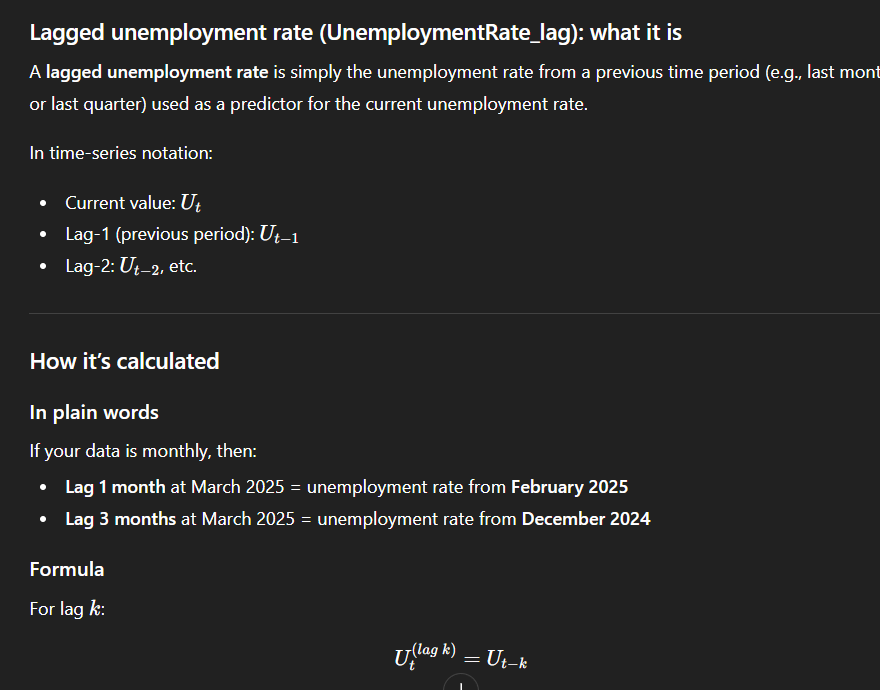


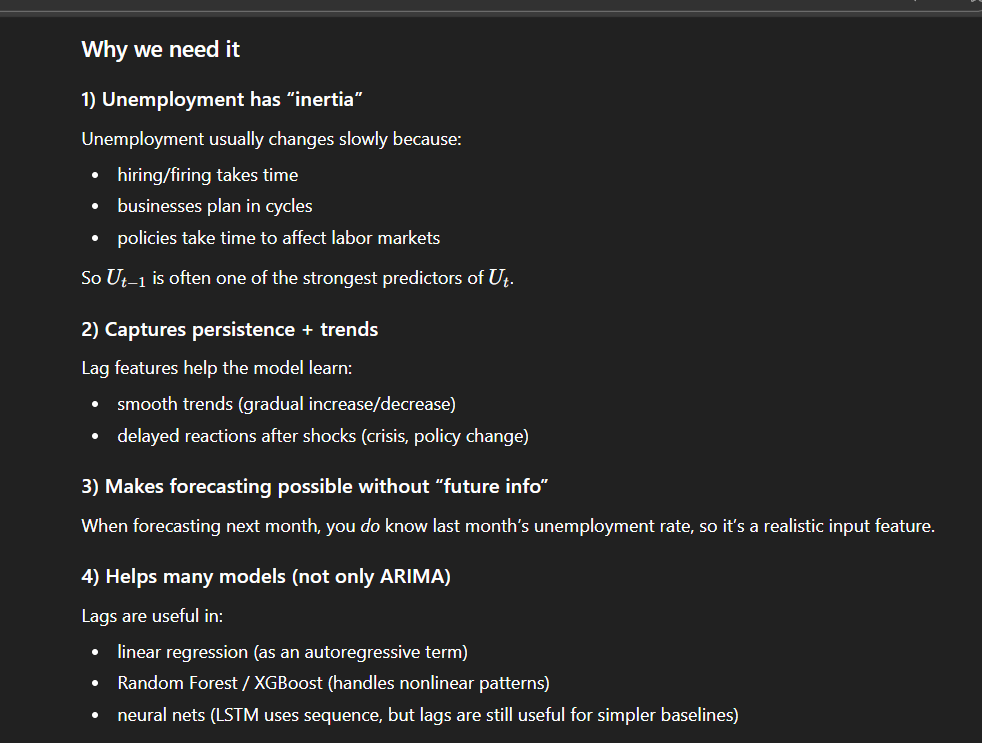

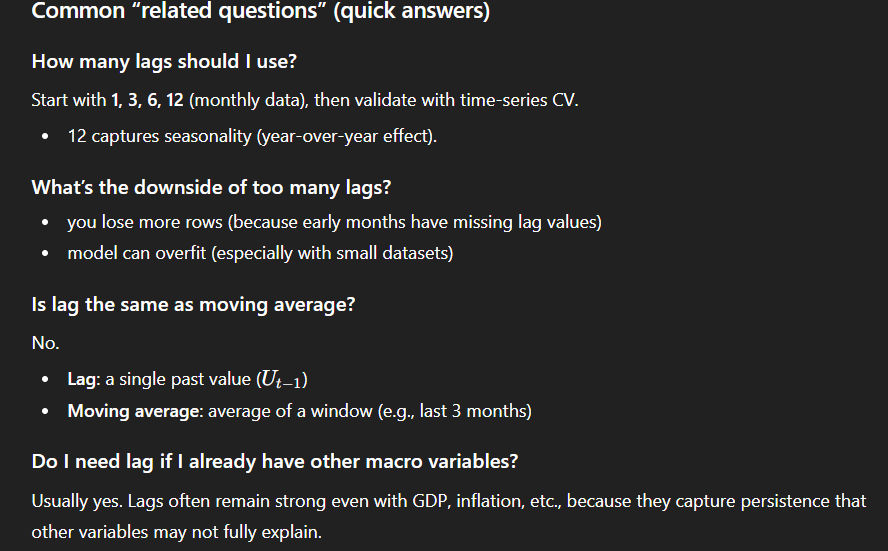

In [116]:
for lag in [1,3,6,12]:
    df[f"lag_{lag}"] = df["UnemploymentRate"].shift(lag)
df_lr = df.dropna()

In [117]:
df_lr.head()

,UnemploymentRate,lag_1,lag_3,lag_6,lag_12
Date,,,,,
2011-01-01,5.6,5.5,5.5,5.6,6.3
2011-02-01,5.5,5.6,5.5,5.6,6.2
2011-03-01,5.5,5.5,5.5,5.6,6.1
2011-04-01,5.5,5.5,5.6,5.5,6.0
2011-05-01,5.4,5.5,5.5,5.5,5.8


### Train-test split

In [131]:
lags = [1,3,6,12]
feat_cols = [f"lag_{l}" for l in lags]

train = df_lr.loc['2015-01-01':'2023-12-01']
test = df_lr.loc['2024-01-01':'2025-12-01']

X_train =  train[feat_cols]
y_train = train['UnemploymentRate']

X_test = test[feat_cols]
y_test = test['UnemploymentRate']

### Linear Regression

In [119]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [120]:
lr_rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
lr_r2 = r2_score(y_test,y_pred_lr)
lr_mae = mean_absolute_error(y_test,y_pred_lr)

print(f'RMSE:{lr_rmse}')
print(f'R2:{lr_r2}')
print(f'MAE:{lr_mae}')

RMSE:0.025634550722521805
R2:0.6495305649357141
MAE:0.016983877372960882


### Arima


In [121]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Train: 2015-01-01 → 2023-12-01 n= 108
Test : 2024-01-01 → 2025-12-01 n= 24

=== ARIMA summary ===
                               SARIMAX Results                                
Dep. Variable:       UnemploymentRate   No. Observations:                  108
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 207.322
Date:                Sun, 01 Feb 2026   AIC                           -408.643
Time:                        17:35:59   BIC                           -400.625
Sample:                    01-01-2015   HQIC                          -405.393
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1       9.349e-09   1.67e-16    5.6e+07      0.000    9.35e-09    9.35e-09
ma.L1      -1.078e-08   1.59e-16 

d:\PROGRAMMING_PROJECTS\DS_COURSE\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\PROGRAMMING_PROJECTS\DS_COURSE\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


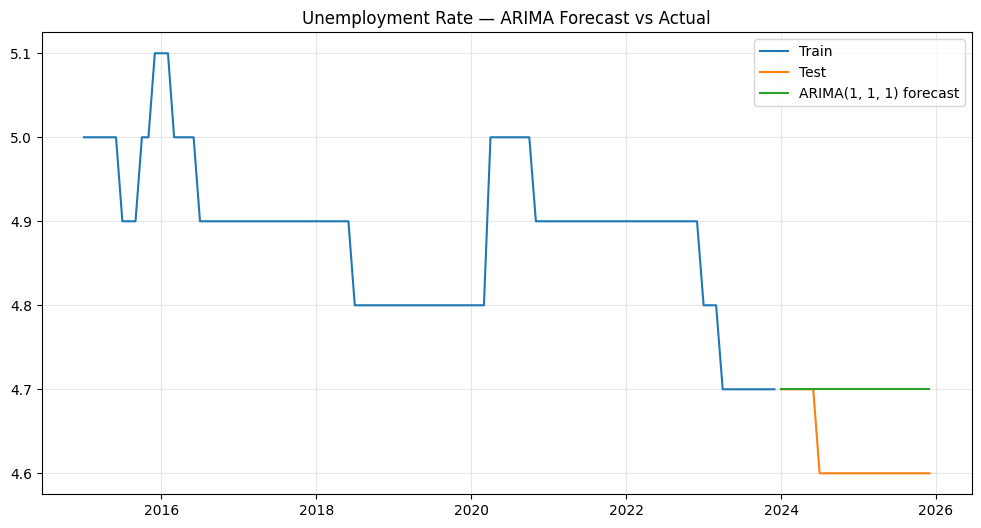

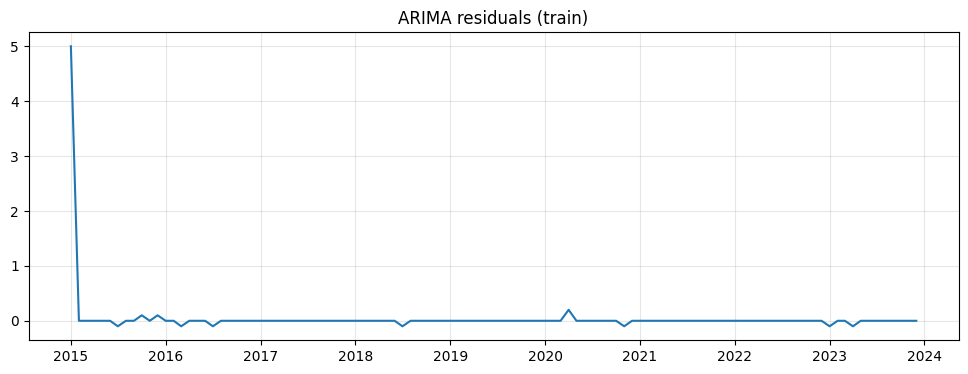

In [122]:

y = df["UnemploymentRate"].astype(float)


y_train = y.loc["2015-01-01":"2023-12-01"]
y_test  = y.loc["2024-01-01":"2025-12-01"]


print("Train:", y_train.index.min().date(), "→", y_train.index.max().date(), "n=", len(y_train))
print("Test :", y_test.index.min().date(),  "→", y_test.index.max().date(),  "n=", len(y_test))


# 3- ARIMA 
order = (1, 1,1)  

model = ARIMA(y_train, order=order)
fit = model.fit()

print("\n=== ARIMA summary ===")
print(fit.summary())


# 4-FORECAST
y_pred = fit.forecast(steps=len(y_test))
y_pred.index = y_test.index  


# 5 - Evaluation 
mae_a  = mean_absolute_error(y_test, y_pred)
rmse_a = np.sqrt(mean_squared_error(y_test, y_pred))
r2_a   = r2_score(y_test, y_pred)

print("\n Test metrics")
print(f"Order: {order}")
print(f"MAE : {mae_a:.4f}")
print(f"RMSE: {rmse_a:.4f}")
print(f"R2  : {r2_a:.4f}")


# 6 - Compare with a naive baseline 
y_pred_naive = y.shift(1).loc[y_test.index].dropna()
aligned_test = y_test.loc[y_pred_naive.index]

naive_mae  = mean_absolute_error(aligned_test, y_pred_naive)
naive_rmse = np.sqrt(mean_squared_error(aligned_test, y_pred_naive))
naive_r2   = r2_score(aligned_test, y_pred_naive)

print("\n Naive baseline (shift(1))")
print(f"MAE : {naive_mae:.4f}")
print(f"RMSE: {naive_rmse:.4f}")
print(f"R2  : {naive_r2:.4f}")


# 7- Plot-> train, test, forecast 
plt.figure(figsize=(12, 6))
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.plot(y_pred, label=f"ARIMA{order} forecast")
plt.title("Unemployment Rate — ARIMA Forecast vs Actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 8- Residual check 
resid = fit.resid
plt.figure(figsize=(12, 4))
plt.plot(resid)
plt.title("ARIMA residuals (train)")
plt.grid(True, alpha=0.3)
plt.show()

### ENET

In [123]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet


In [124]:
train = df_lr.loc["2015-01-01":"2023-12-01"]
test  = df_lr.loc["2024-01-01":"2025-12-01"]

X_train = train[feat_cols]
y_train = train["UnemploymentRate"]

X_test = test[feat_cols]
y_test = test["UnemploymentRate"]

Elastic Net metrics (test)
MAE : 0.033077
RMSE: 0.038106
R2  : 0.225572


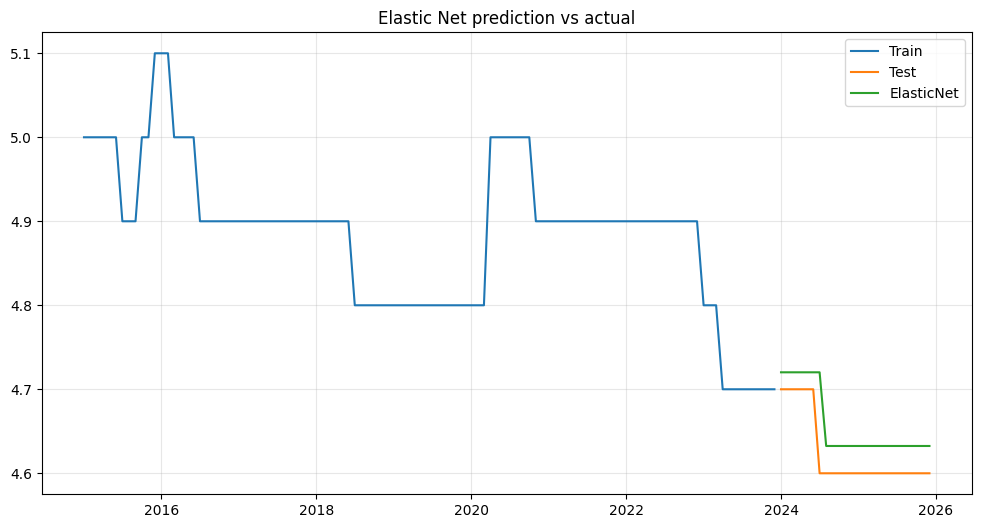

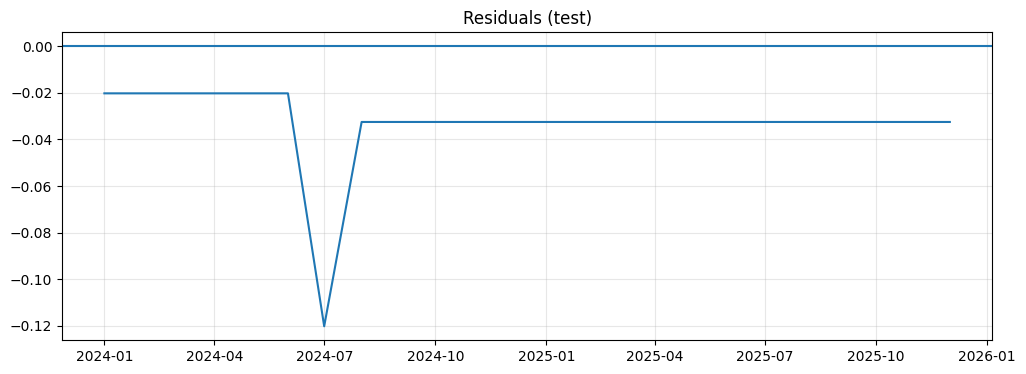

In [125]:
enet = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
])

enet.fit(X_train, y_train)

y_pred = enet.predict(X_test)
y_pred = pd.Series(y_pred, index=y_test.index)

enet_mae = mean_absolute_error(y_test, y_pred)
enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
enet_r2= r2_score(y_test, y_pred)

print("Elastic Net metrics (test)")
print("MAE :", round(enet_mae, 6))
print("RMSE:", round(enet_rmse, 6))
print("R2  :", round(enet_r2,6))

plt.figure(figsize=(12, 6))
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="ElasticNet")
plt.title("Elastic Net prediction vs actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

resid = y_test - y_pred
plt.figure(figsize=(12, 4))
plt.plot(resid)
plt.axhline(0)
plt.title("Residuals (test)")
plt.grid(True, alpha=0.3)
plt.show()


### MSAE

In [133]:
def mase(y_true, y_pred, y_train, m=1):
    """
    Mean Absolute Scaled Error (MASE)
    scale = mean absolute error of seasonal-naive (lag m) inside the TRAIN set
    m=1  -> non-seasonal scaling
    m=12 -> seasonal scaling for monthly data
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)

    mae = np.mean(np.abs(y_true - y_pred))
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return np.nan if scale == 0 else mae / scale


In [134]:
train_ts = y.loc["2015-01-01":"2023-12-01"].dropna()
test_ts  = y.loc["2024-01-01":"2025-12-01"].dropna()

# --- Ensure predictions are aligned to test_ts.index ---
pred_naive = y.shift(1).loc[test_ts.index]  # your naive baseline

# linreg prediction vector -> Series aligned to y_test index, then align to test_ts
pred_lr = pd.Series(y_pred_lr, index=y_test.index).reindex(test_ts.index)

# elastic net prediction vector -> Series aligned to y_test index, then align to test_ts
pred_enet = pd.Series(y_pred_enet, index=y_test.index).reindex(test_ts.index)

# arima forecast should already match the test length; force index alignment
pred_arima = pd.Series(y_pred_a, index=test_ts.index)  # (use your ARIMA forecast variable)


# --- MASE values (m=1). For monthly seasonality use m=12 ---
mase_naive = mase(test_ts, pred_naive, train_ts, m=1)
mase_linreg = mase(test_ts, pred_lr, train_ts, m=1)
mase_elastic_net = mase(test_ts, pred_enet, train_ts, m=1)
mase_arima = mase(test_ts, pred_arima, train_ts, m=1)

print("MASE naive:", mase_naive)
print("MASE linreg:", mase_linreg)
print("MASE elastic_net:", mase_elastic_net)
print("MASE arima:", mase_arima)

MASE naive: 0.40530303030303294
MASE linreg: 1.6520680717334695
MASE elastic_net: 3.2174871125551383
MASE arima: 15.869670812538697


In [135]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# 1) take the unemployment column and make sure it's monthly
y = df["UnemploymentRate"].asfreq("MS").dropna()

# 2) split train / test same as before
train_ts = y.loc["2015-01-01":"2023-12-01"]
test_ts  = y.loc["2024-01-01":"2025-12-01"]

# 3) MASE (scaled by naive errors inside training)
def mase(y_true, y_pred, train_data, m=1):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    train_data = np.array(train_data)

    mae = np.mean(np.abs(y_true - y_pred))
    scale = np.mean(np.abs(train_data[m:] - train_data[:-m]))  # naive scale
    if scale == 0:
        return np.nan
    return mae / scale

# 4) helper for metrics
def get_metrics(true_vals, pred_vals, train_vals, m=1):
    mae = mean_absolute_error(true_vals, pred_vals)
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    r2 = r2_score(true_vals, pred_vals)
    ms = mase(true_vals, pred_vals, train_vals, m=m)
    return mae, rmse, r2, ms

# 5) fit ETS models and save results
rows = []

# --- SES: level only ---
ses = SimpleExpSmoothing(train_ts, initialization_method="estimated").fit()
ses_pred = ses.forecast(len(test_ts))
ses_pred.index = test_ts.index

mae, rmse, r2, ms = get_metrics(test_ts, ses_pred, train_ts, m=1)
rows.append(["ETS (SES level)", mae, rmse, r2, ms])

# --- Holt: trend + damped ---
holt = ExponentialSmoothing(
    train_ts, trend="add", damped_trend=True, seasonal=None,
    initialization_method="estimated"
).fit()
holt_pred = holt.forecast(len(test_ts))
holt_pred.index = test_ts.index

mae, rmse, r2, ms = get_metrics(test_ts, holt_pred, train_ts, m=1)
rows.append(["ETS (Holt damped)", mae, rmse, r2, ms])

# --- Seasonal ETS (optional) ---
# I only try it because data is monthly (12). If it fails, I just skip it.
try:
    seas = ExponentialSmoothing(
        train_ts, trend="add", damped_trend=True,
        seasonal="add", seasonal_periods=12,
        initialization_method="estimated"
    ).fit()
    seas_pred = seas.forecast(len(test_ts))
    seas_pred.index = test_ts.index

    mae, rmse, r2, ms = get_metrics(test_ts, seas_pred, train_ts, m=12)
    rows.append(["ETS (Seasonal 12)", mae, rmse, r2, ms])
except:
    print("Seasonal ETS didn't work, skipping it.")

# 6) show results (same columns as before)
ets_table = pd.DataFrame(rows, columns=["model", "MAE", "RMSE", "R2", "MASE"])
print(ets_table.sort_values("RMSE"))

# 7) choose best model (by RMSE)
best_name = ets_table.sort_values("RMSE").iloc[0]["model"]
print("\nBest ETS model (by RMSE):", best_name)

# 8) forecast future 12 months using SES on full data (simple + common)
H = 12
ses_full = SimpleExpSmoothing(y, initialization_method="estimated").fit()
future_fc = ses_full.forecast(H)

print("\nNext 12-month forecast (SES):")
print(future_fc)


               model       MAE      RMSE        R2      MASE
2  ETS (Seasonal 12)  0.047053  0.052512 -0.470659  0.618780
1  ETS (Holt damped)  0.054833  0.062007 -1.050586  5.333743
0    ETS (SES level)  0.075000  0.086603 -3.000000  7.295455

Best ETS model (by RMSE): ETS (Seasonal 12)

Next 12-month forecast (SES):
2026-01-01    4.6
2026-02-01    4.6
2026-03-01    4.6
2026-04-01    4.6
2026-05-01    4.6
2026-06-01    4.6
2026-07-01    4.6
2026-08-01    4.6
2026-09-01    4.6
2026-10-01    4.6
2026-11-01    4.6
2026-12-01    4.6
Freq: MS, dtype: float64


1–3 MONTH FORECAST (RECURSIVE)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

train_ts = y.loc["2015-01-01":"2023-12-01"]
test_ts  = y.loc["2024-01-01":"2025-12-01"]

def mase(y_true, y_pred, y_train, m=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)
    mae = np.mean(np.abs(y_true - y_pred))
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return np.nan if scale == 0 else mae / scale

def eval_all(y_true, y_pred, y_train):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mase1 = mase(y_true, y_pred, y_train, m=1)
    mase12 = mase(y_true, y_pred, y_train, m=12) if len(y_train) > 12 else np.nan
    return mae, rmse, r2, mase1, mase12

rows = []

# --- 1) SES (level) ---
ses_fit = SimpleExpSmoothing(train_ts, initialization_method="estimated").fit()
ses_pred = ses_fit.forecast(len(test_ts))
ses_pred.index = test_ts.index
rows.append(["ETS-SES (level)", *eval_all(test_ts, ses_pred, train_ts)])

# --- 2) Holt damped ---
holt_fit = ExponentialSmoothing(
    train_ts, trend="add", damped_trend=True, seasonal=None,
    initialization_method="estimated"
).fit()
holt_pred = holt_fit.forecast(len(test_ts))
holt_pred.index = test_ts.index
rows.append(["ETS-Holt (damped)", *eval_all(test_ts, holt_pred, train_ts)])

# --- 3) Seasonal 12 (try) ---
seasonal_ok = True
try:
    seas_fit = ExponentialSmoothing(
        train_ts, trend="add", damped_trend=True,
        seasonal="add", seasonal_periods=12,
        initialization_method="estimated"
    ).fit()
    seas_pred = seas_fit.forecast(len(test_ts))
    seas_pred.index = test_ts.index
    rows.append(["ETS-Seasonal (12)", *eval_all(test_ts, seas_pred, train_ts)])
except Exception as e:
    seasonal_ok = False
    print("Seasonal ETS failed:", e)

ets_table = pd.DataFrame(rows, columns=["model","MAE","RMSE","R2","MASE_m1","MASE_m12"])
print(ets_table.sort_values("RMSE"))

# --- Forecast next 12 months using the best ETS model (by RMSE) ---
best_model = ets_table.sort_values("RMSE").iloc[0]["model"]
print("\nBest ETS by RMSE:", best_model)

H = 12

if best_model == "ETS-SES (level)":
    best_fit_full = SimpleExpSmoothing(y, initialization_method="estimated").fit()
elif best_model == "ETS-Holt (damped)":
    best_fit_full = ExponentialSmoothing(
        y, trend="add", damped_trend=True, seasonal=None,
        initialization_method="estimated"
    ).fit()
else:
    # Seasonal 12
    best_fit_full = ExponentialSmoothing(
        y, trend="add", damped_trend=True, seasonal="add", seasonal_periods=12,
        initialization_method="estimated"
    ).fit()

future_fc = best_fit_full.forecast(H)
print("\nNext 12-month forecast (best ETS):")
print(future_fc)


               model       MAE      RMSE        R2   MASE_m1  MASE_m12
2  ETS-Seasonal (12)  0.047053  0.052512 -0.470659  4.576977  0.618780
1  ETS-Holt (damped)  0.054833  0.062007 -1.050586  5.333743  0.721090
0    ETS-SES (level)  0.075000  0.086603 -3.000000  7.295455  0.986301

Best ETS by RMSE: ETS-Seasonal (12)

Next 12-month forecast (best ETS):
2026-01-01    4.599515
2026-02-01    4.600631
2026-03-01    4.594220
2026-04-01    4.599194
2026-05-01    4.590693
2026-06-01    4.575090
2026-07-01    4.552490
2026-08-01    4.560497
2026-09-01    4.574181
2026-10-01    4.581117
2026-11-01    4.587623
2026-12-01    4.600000
Freq: MS, dtype: float64


In [138]:
history = list(y.loc[: "2025-12-01"].values)  
preds = []
H = 3

last_obs_date = y.index.max()

for _ in range(H):
    x = np.array([history[-1], history[-3], history[-6], history[-12]]).reshape(1, -1)
    yhat = enet.predict(x)[0]
    preds.append(yhat)
    history.append(yhat)

future_idx = pd.date_range(last_obs_date + pd.offsets.MonthBegin(1), periods=H, freq="MS")
enet_forecast = pd.Series(preds, index=future_idx, name="ElasticNet_recursive_forecast")

print("Last obs date:", last_obs_date.date())
print(enet_forecast)

Last obs date: 2025-12-01
2026-01-01    4.632494
2026-02-01    4.660996
2026-03-01    4.685995
Freq: MS, Name: ElasticNet_recursive_forecast, dtype: float64


d:\PROGRAMMING_PROJECTS\DS_COURSE\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\PROGRAMMING_PROJECTS\DS_COURSE\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\PROGRAMMING_PROJECTS\DS_COURSE\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Model Comparison

In [127]:
# import sys
# !"{sys.executable}" -m pip install tabulate


In [128]:
from tabulate import tabulate

rows = [
    ["naive",        naive_mae,naive_rmse, naive_r2],
    ["linreg",      lr_mae,lr_rmse,lr_r2 ],
    ["elastic_net",  enet_mae,enet_rmse,enet_r2],
    ["arima(1,1,1)", mae_a,rmse_a,r2_a]
]

print(tabulate(rows, headers=["model", "MAE", "RMSE", "R2"], tablefmt="github"))

| model        |        MAE |      RMSE |        R2 |
|--------------|------------|-----------|-----------|
| naive        | 0.00416667 | 0.0204124 |  0.777778 |
| linreg       | 0.0169839  | 0.0256346 |  0.649531 |
| elastic_net  | 0.033077   | 0.0381058 |  0.225572 |
| arima(1,1,1) | 0.075      | 0.0866025 | -3        |


### Brief Conclusion